# 决策树算法对比实验

本实验对比三种经典决策树算法（ID3、C4.5、CART）以及sklearn的实现，使用包含连续特征的西瓜数据集。

## 实验内容
1. **ID3算法** - 使用信息增益作为分裂标准
2. **C4.5算法** - 使用信息增益率作为分裂标准
3. **CART算法** - 使用基尼指数作为分裂标准
4. **sklearn实现** - sklearn.tree.DecisionTreeClassifier

## 数据集说明
- 训练集：Watermelon-train2.csv (17个样本)
- 测试集：Watermelon-test2.csv (5个样本)
- 特征：色泽、根蒂、敲声、纹理（离散特征）+ 密度（连续特征）
- 目标：好瓜（是/否）


In [ ]:
# 1. 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 导入自定义的决策树实现
from decision_tree_ID3 import DecisionTreeContinuous as ID3Tree
from decision_tree_ID3 import DecisionTreeID3 as ID3Tree_simple
from decision_tree_C45 import DecisionTreeC45
from decision_tree_CART import DecisionTreeCART

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 创建pic文件夹用于保存图片
pic_dir='pic'
print("✓ 库导入成功！")


✓ 库导入成功！


## 2. 加载和预处理数据集


In [69]:
# 加载数据
train_data = pd.read_csv('Watermelon-train2.csv')
test_data = pd.read_csv('Watermelon-test2.csv')

print("训练集数据：")
print(train_data.head())
print(f"\n训练集形状: {train_data.shape}")
print(f"测试集形状: {test_data.shape}")

# 查看数据信息
print("\n数据信息：")
print(train_data.info())

# 查看类别分布
print("\n训练集类别分布：")
print(train_data['好瓜'].value_counts())


训练集数据：
   编号  色泽  根蒂  敲声  纹理     密度 好瓜
0   1  青绿  蜷缩  浊响  清晰  0.697  是
1   2  乌黑  蜷缩  沉闷  清晰  0.774  是
2   3  乌黑  蜷缩  浊响  清晰  0.634  是
3   4  青绿  蜷缩  沉闷  清晰  0.608  是
4   5  浅白  蜷缩  浊响  清晰  0.556  是

训练集形状: (17, 7)
测试集形状: (5, 7)

数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   编号      17 non-null     int64  
 1   色泽      17 non-null     object 
 2   根蒂      17 non-null     object 
 3   敲声      17 non-null     object 
 4   纹理      17 non-null     object 
 5   密度      17 non-null     float64
 6   好瓜      17 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.1+ KB
None

训练集类别分布：
好瓜
否    9
是    8
Name: count, dtype: int64


In [70]:
# 数据预处理
# 分离特征和目标变量
X_train = train_data.drop(['编号', '好瓜'], axis=1)
y_train = train_data['好瓜']

X_test = test_data.drop(['编号', '好瓜'], axis=1)
y_test = test_data['好瓜']

# 为sklearn准备编码后的数据
# sklearn需要数值型输入，所以需要对离散特征进行编码
label_encoders = {}
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 对离散特征进行标签编码
discrete_features = ['色泽', '根蒂', '敲声', '纹理']
for feature in discrete_features:
    le = LabelEncoder()
    X_train_encoded[feature] = le.fit_transform(X_train[feature])
    X_test_encoded[feature] = le.transform(X_test[feature])
    label_encoders[feature] = le

print("原始特征数据（前5行）：")
print(X_train.head())

print("\n编码后的特征数据（前5行）：")
print(X_train_encoded.head())

print(f"\n特征列表：{X_train.columns.tolist()}")
print(f"连续特征：['密度']")
print(f"离散特征：{discrete_features}")


原始特征数据（前5行）：
   色泽  根蒂  敲声  纹理     密度
0  青绿  蜷缩  浊响  清晰  0.697
1  乌黑  蜷缩  沉闷  清晰  0.774
2  乌黑  蜷缩  浊响  清晰  0.634
3  青绿  蜷缩  沉闷  清晰  0.608
4  浅白  蜷缩  浊响  清晰  0.556

编码后的特征数据（前5行）：
   色泽  根蒂  敲声  纹理     密度
0   2   2   1   1  0.697
1   0   2   0   1  0.774
2   0   2   1   1  0.634
3   2   2   0   1  0.608
4   1   2   1   1  0.556

特征列表：['色泽', '根蒂', '敲声', '纹理', '密度']
连续特征：['密度']
离散特征：['色泽', '根蒂', '敲声', '纹理']


## 3. 训练ID3决策树（支持连续特征）


In [71]:
# 训练ID3决策树（使用信息增益）
print("="*60)
print("训练ID3决策树（使用信息增益）")
print("="*60)

id3_tree = ID3Tree(
    min_samples_split=2,
    continuous_features=['密度']  # 指定连续特征
)

# 训练（会输出详细的构建过程）
id3_tree.fit(X_train, y_train)


训练ID3决策树（使用信息增益）


In [72]:
# ID3预测和评估
id3_train_pred = id3_tree.predict(X_train)
id3_test_pred = id3_tree.predict(X_test)

id3_train_acc = accuracy_score(y_train, id3_train_pred)
id3_test_acc = accuracy_score(y_test, id3_test_pred)

print("\nID3决策树性能：")
print("-" * 40)
print(f"训练集准确率: {id3_train_acc:.4f} ({id3_train_acc*100:.2f}%)")
print(f"测试集准确率: {id3_test_acc:.4f} ({id3_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, id3_test_pred, target_names=['否', '是']))



ID3决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 4. 训练C4.5决策树


In [73]:
# 训练C4.5决策树（使用信息增益率）
print("="*60)
print("训练C4.5决策树（使用信息增益率）")
print("="*60)

c45_tree = DecisionTreeC45(
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    continuous_features=['密度']
)

# 训练
c45_tree.fit(X_train, y_train)


训练C4.5决策树（使用信息增益率）


In [74]:
# C4.5预测和评估
c45_train_pred = c45_tree.predict(X_train)
c45_test_pred = c45_tree.predict(X_test)

c45_train_acc = accuracy_score(y_train, c45_train_pred)
c45_test_acc = accuracy_score(y_test, c45_test_pred)

print("\nC4.5决策树性能：")
print("-" * 40)
print(f"训练集准确率: {c45_train_acc:.4f} ({c45_train_acc*100:.2f}%)")
print(f"测试集准确率: {c45_test_acc:.4f} ({c45_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, c45_test_pred, target_names=['否', '是']))



C4.5决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 5. 训练CART决策树


In [75]:
# 训练CART决策树（使用基尼指数）
print("="*60)
print("训练CART决策树（使用基尼指数）")
print("="*60)

cart_tree = DecisionTreeCART(
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    continuous_features=['密度']
)

# 训练
cart_tree.fit(X_train, y_train)


训练CART决策树（使用基尼指数）


In [76]:
# CART预测和评估
cart_train_pred = cart_tree.predict(X_train)
cart_test_pred = cart_tree.predict(X_test)

cart_train_acc = accuracy_score(y_train, cart_train_pred)
cart_test_acc = accuracy_score(y_test, cart_test_pred)

print("\nCART决策树性能：")
print("-" * 40)
print(f"训练集准确率: {cart_train_acc:.4f} ({cart_train_acc*100:.2f}%)")
print(f"测试集准确率: {cart_test_acc:.4f} ({cart_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, cart_test_pred, target_names=['否', '是']))



CART决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.6000 (60.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.50      1.00      0.67         2
           是       1.00      0.33      0.50         3

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
weighted avg       0.80      0.60      0.57         5



## 6. 训练sklearn决策树


In [77]:
# 训练sklearn决策树 - 使用不同的分裂标准
print("="*60)
print("训练sklearn决策树")
print("="*60)

# 1. 使用信息熵（类似ID3/C4.5）
sklearn_entropy = DecisionTreeClassifier(
    criterion='entropy',  # 使用信息熵
    random_state=42
)
sklearn_entropy.fit(X_train_encoded, y_train)

# 2. 使用基尼指数（类似CART）
sklearn_gini = DecisionTreeClassifier(
    criterion='gini',  # 使用基尼指数
    random_state=42
)
sklearn_gini.fit(X_train_encoded, y_train)

print("✓ sklearn决策树训练完成（包括entropy和gini两种标准）")


训练sklearn决策树
✓ sklearn决策树训练完成（包括entropy和gini两种标准）


In [78]:
# sklearn决策树预测和评估
# 1. Entropy版本
sklearn_entropy_train_pred = sklearn_entropy.predict(X_train_encoded)
sklearn_entropy_test_pred = sklearn_entropy.predict(X_test_encoded)

sklearn_entropy_train_acc = accuracy_score(y_train, sklearn_entropy_train_pred)
sklearn_entropy_test_acc = accuracy_score(y_test, sklearn_entropy_test_pred)

print("\nsklearn决策树（criterion='entropy'）性能：")
print("-" * 40)
print(f"训练集准确率: {sklearn_entropy_train_acc:.4f} ({sklearn_entropy_train_acc*100:.2f}%)")
print(f"测试集准确率: {sklearn_entropy_test_acc:.4f} ({sklearn_entropy_test_acc*100:.2f}%)")

# 2. Gini版本
sklearn_gini_train_pred = sklearn_gini.predict(X_train_encoded)
sklearn_gini_test_pred = sklearn_gini.predict(X_test_encoded)

sklearn_gini_train_acc = accuracy_score(y_train, sklearn_gini_train_pred)
sklearn_gini_test_acc = accuracy_score(y_test, sklearn_gini_test_pred)

print("\nsklearn决策树（criterion='gini'）性能：")
print("-" * 40)
print(f"训练集准确率: {sklearn_gini_train_acc:.4f} ({sklearn_gini_train_acc*100:.2f}%)")
print(f"测试集准确率: {sklearn_gini_test_acc:.4f} ({sklearn_gini_test_acc*100:.2f}%)")

print("\n测试集分类报告（entropy）：")
print(classification_report(y_test, sklearn_entropy_test_pred, target_names=['否', '是']))

print("\n测试集分类报告（gini）：")
print(classification_report(y_test, sklearn_gini_test_pred, target_names=['否', '是']))



sklearn决策树（criterion='entropy'）性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

sklearn决策树（criterion='gini'）性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告（entropy）：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5


测试集分类报告（gini）：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 7. 性能对比和可视化


In [79]:
# 汇总所有模型的性能
results = pd.DataFrame({
    '算法': ['ID3 (Information Gain)', 'C4.5 (Gain Ratio)', 'CART (Gini Index)', 
                  'sklearn-Entropy', 'sklearn-Gini'],
    '训练集准确率': [id3_train_acc, c45_train_acc, cart_train_acc, 
                      sklearn_entropy_train_acc, sklearn_gini_train_acc],
    '测试集准确率': [id3_test_acc, c45_test_acc, cart_test_acc,
                    sklearn_entropy_test_acc, sklearn_gini_test_acc]
})

print("="*60)
print("所有模型性能对比汇总")
print("="*60)
print(results.to_string(index=False))
print("="*60)


所有模型性能对比汇总
                    算法  训练集准确率  测试集准确率
ID3 (Information Gain)     1.0     0.8
     C4.5 (Gain Ratio)     1.0     0.8
     CART (Gini Index)     1.0     0.6
       sklearn-Entropy     1.0     0.8
          sklearn-Gini     1.0     0.8


图片已保存: pic/1_accuracy_comparison.png


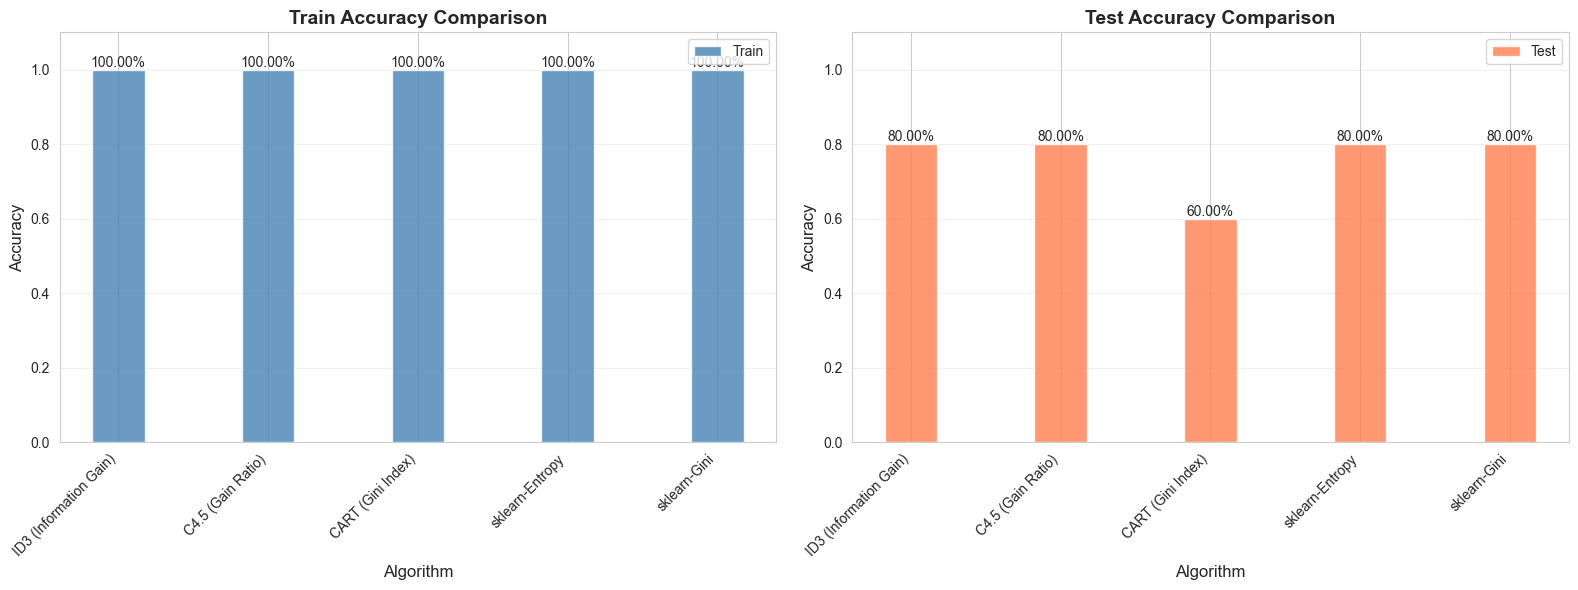

In [80]:
# 可视化1：准确率对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 训练集准确率对比
ax1 = axes[0]
x = np.arange(len(results))
width = 0.35

bars1 = ax1.bar(x, results['训练集准确率'], width, label='Train', 
                color='steelblue', alpha=0.8)
ax1.set_xlabel('Algorithm', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Train Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results['算法'], rotation=45, ha='right')
ax1.set_ylim([0, 1.1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels to bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=10)

# 测试集准确率对比
ax2 = axes[1]
bars2 = ax2.bar(x, results['测试集准确率'], width, label='Test',
                color='coral', alpha=0.8)
ax2.set_xlabel('Algorithm', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results['算法'], rotation=45, ha='right')
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 在柱状图上添加数值
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{pic_dir}/1_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print(f"图片已保存: {pic_dir}/1_accuracy_comparison.png")
plt.show()


 图片已保存: pic/2_train_test_accuracy_comparison.png


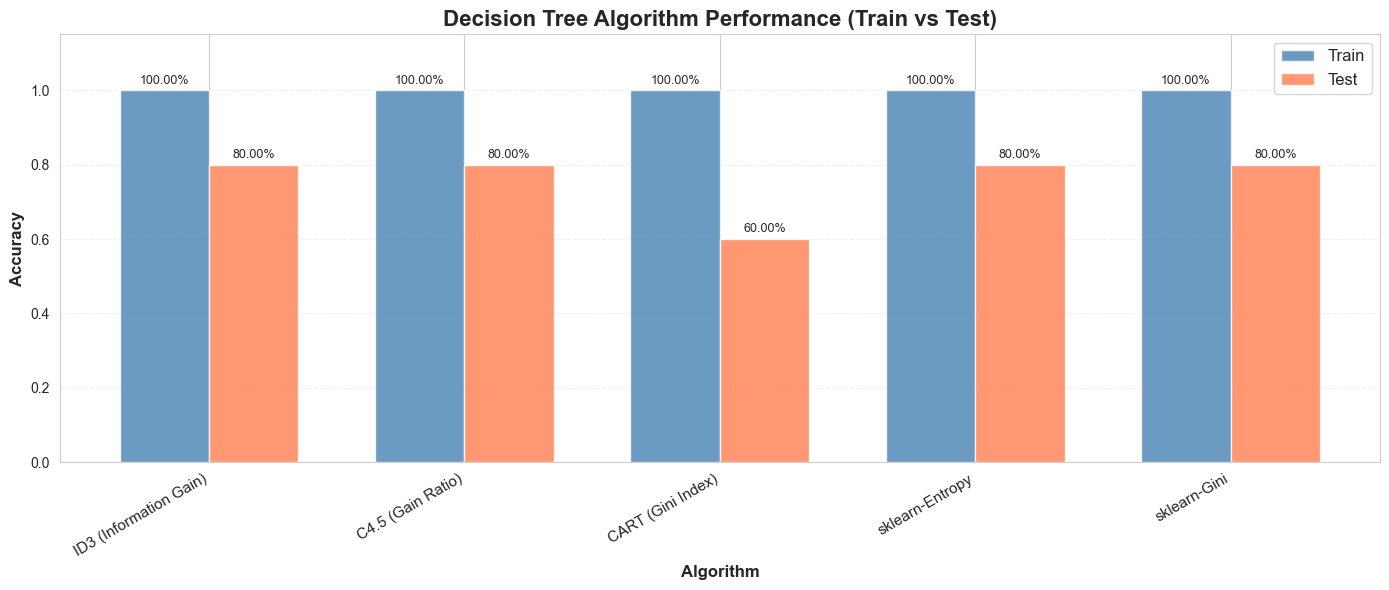

In [81]:
# 可视化2：训练集vs测试集准确率对比（并排）
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['训练集准确率'], width, 
               label='Train', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, results['测试集准确率'], width,
               label='Test', color='coral', alpha=0.8)

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Decision Tree Algorithm Performance (Train vs Test)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['算法'], rotation=30, ha='right', fontsize=11)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{pic_dir}/2_train_test_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print(f" 图片已保存: {pic_dir}/2_train_test_accuracy_comparison.png")
plt.show()


图片已保存: pic/3_confusion_matrix_comparison.png


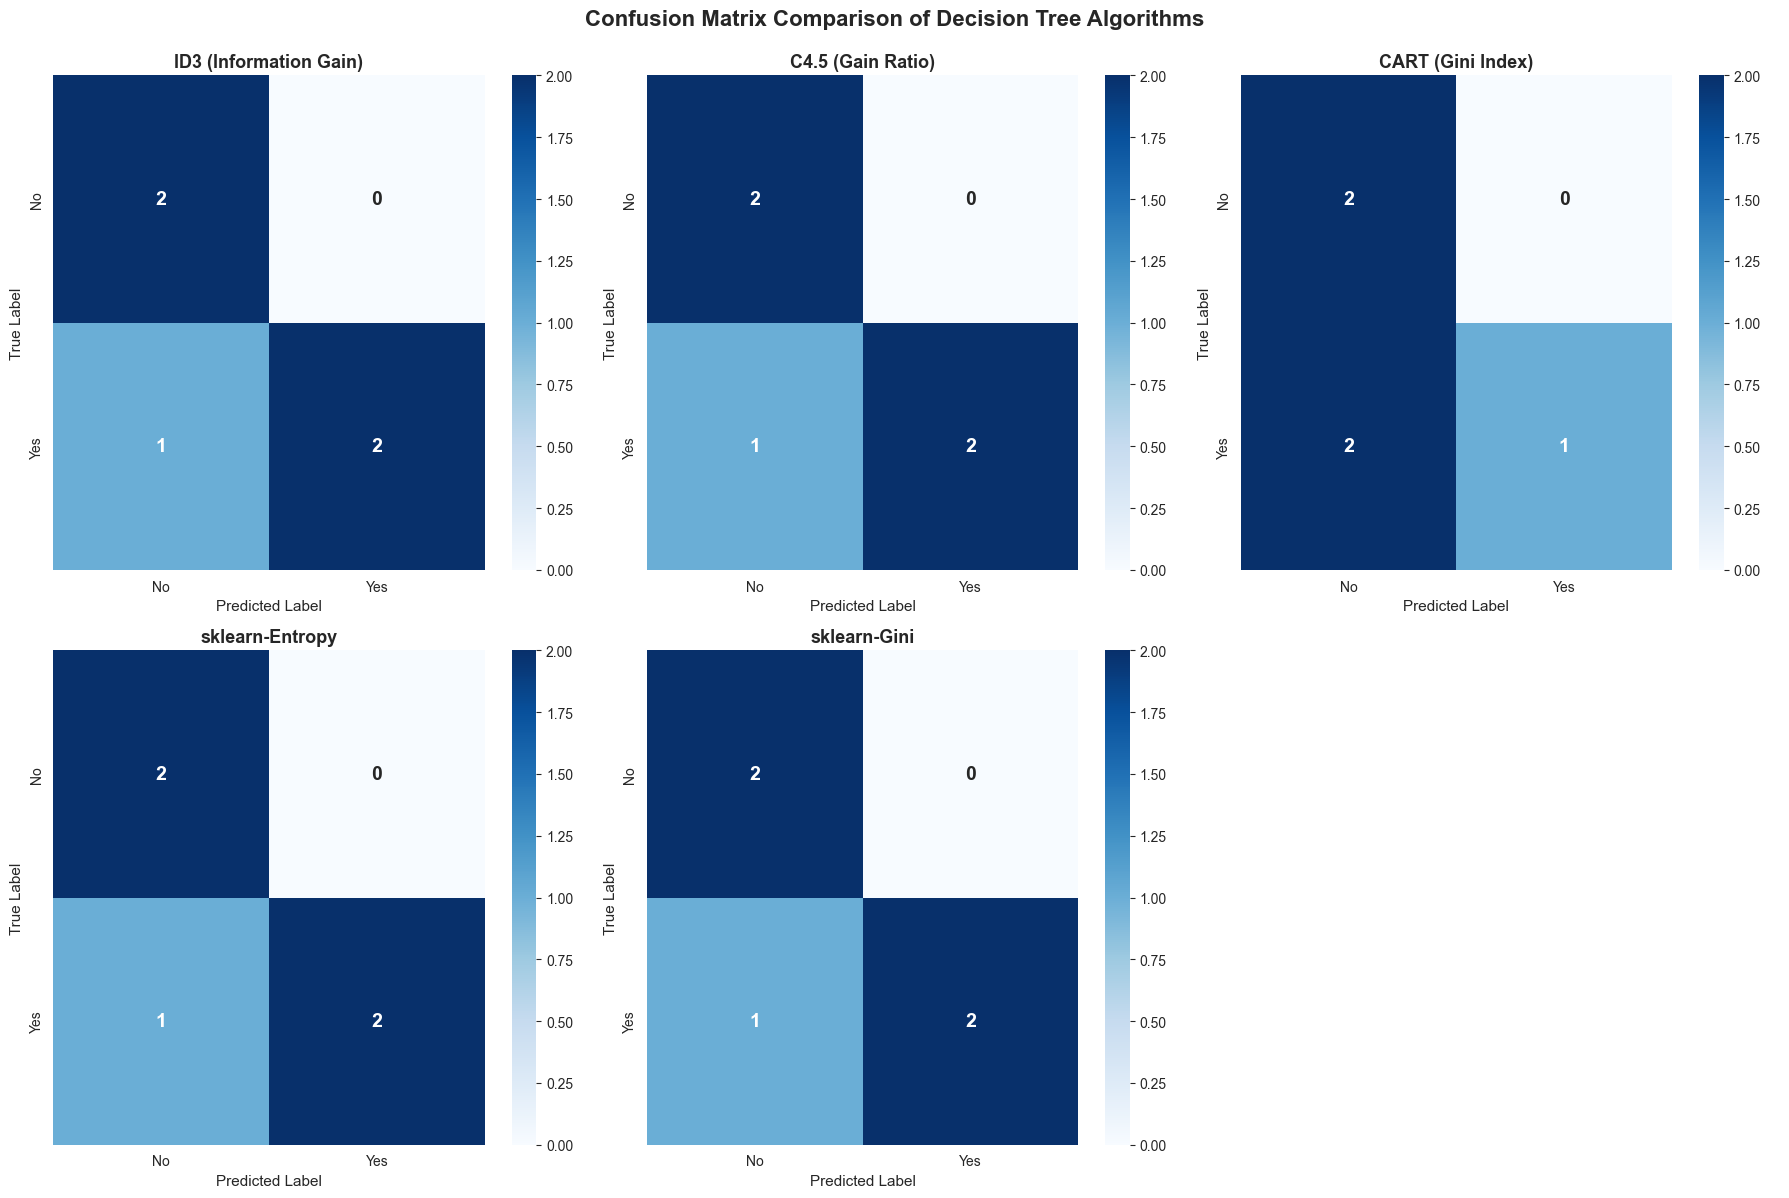

In [82]:
# 可视化3：混淆矩阵对比
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models = [
    ('ID3 (Information Gain)', id3_test_pred),
    ('C4.5 (Gain Ratio)', c45_test_pred),
    ('CART (Gini Index)', cart_test_pred),
    ('sklearn-Entropy', sklearn_entropy_test_pred),
    ('sklearn-Gini', sklearn_gini_test_pred)
]

label_map = {'否': 'No', '是': 'Yes'}
english_labels = ['No', 'Yes']

for i, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test.map(label_map), pd.Series(pred).map(label_map), labels=english_labels)
    
    # Draw confusion matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=english_labels,
        yticklabels=english_labels,
        ax=axes[i], cbar=True,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('True Label', fontsize=11)

# Hide the 6th subplot
axes[5].axis('off')

plt.suptitle('Confusion Matrix Comparison of Decision Tree Algorithms', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{pic_dir}/3_confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print(f"图片已保存: {pic_dir}/3_confusion_matrix_comparison.png")
plt.show()


In [86]:
# 计算各算法的特征重要性
print("="*60)
print("特征重要性对比分析")
print("="*60)

# ID3特征重要性
id3_importance = id3_tree.get_feature_importances()
print("\nID3算法特征重要性（基于信息增益）：")
for feature, importance in sorted(id3_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f} ({importance*100:.2f}%)")

# C4.5特征重要性
c45_importance = c45_tree.get_feature_importances()
print("\nC4.5算法特征重要性（基于信息增益率）：")
for feature, importance in sorted(c45_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f} ({importance*100:.2f}%)")

# CART特征重要性
cart_importance = cart_tree.get_feature_importances()
print("\nCART算法特征重要性（基于基尼不纯度减少量）：")
for feature, importance in sorted(cart_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f} ({importance*100:.2f}%)")

# sklearn特征重要性（注意：sklearn使用的是编码后的数据，特征顺序与原始数据一致）
# 由于我们使用的是LabelEncoder，特征顺序保持不变，可以直接映射
sklearn_entropy_importance = dict(zip(X_train.columns, sklearn_entropy.feature_importances_))
sklearn_gini_importance = dict(zip(X_train.columns, sklearn_gini.feature_importances_))

print("\nsklearn-Entropy特征重要性：")
for feature, importance in sorted(sklearn_entropy_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f} ({importance*100:.2f}%)")

print("\nsklearn-Gini特征重要性：")
for feature, importance in sorted(sklearn_gini_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f} ({importance*100:.2f}%)")


特征重要性对比分析

ID3算法特征重要性（基于信息增益）：
  密度: 0.6185 (61.85%)
  纹理: 0.3815 (38.15%)

C4.5算法特征重要性（基于信息增益率）：
  密度: 0.6087 (60.87%)
  纹理: 0.3913 (39.13%)

CART算法特征重要性（基于基尼不纯度减少量）：
  纹理: 0.4261 (42.61%)
  密度: 0.3673 (36.73%)
  敲声: 0.1181 (11.81%)
  色泽: 0.0885 (8.85%)

sklearn-Entropy特征重要性：
  纹理: 0.5240 (52.40%)
  密度: 0.4760 (47.60%)
  色泽: 0.0000 (0.00%)
  根蒂: 0.0000 (0.00%)
  敲声: 0.0000 (0.00%)

sklearn-Gini特征重要性：
  纹理: 0.5376 (53.76%)
  密度: 0.4624 (46.24%)
  色泽: 0.0000 (0.00%)
  根蒂: 0.0000 (0.00%)
  敲声: 0.0000 (0.00%)


In [87]:
# 创建特征重要性对比DataFrame
all_features = list(X_train.columns)
importance_df = pd.DataFrame({
    '特征': all_features,
    'ID3': [id3_importance.get(f, 0) for f in all_features],
    'C4.5': [c45_importance.get(f, 0) for f in all_features],
    'CART': [cart_importance.get(f, 0) for f in all_features],
    'sklearn-Entropy': [sklearn_entropy_importance.get(f, 0) for f in all_features],
    'sklearn-Gini': [sklearn_gini_importance.get(f, 0) for f in all_features]
})

print("\n特征重要性对比表：")
print("="*80)
print(importance_df.to_string(index=False))
print("="*80)



特征重要性对比表：
特征      ID3     C4.5     CART  sklearn-Entropy  sklearn-Gini
色泽 0.000000 0.000000 0.088542          0.00000      0.000000
根蒂 0.000000 0.000000 0.000000          0.00000      0.000000
敲声 0.000000 0.000000 0.118056          0.00000      0.000000
纹理 0.381545 0.391311 0.426119          0.52404      0.537607
密度 0.618455 0.608689 0.367284          0.47596      0.462393


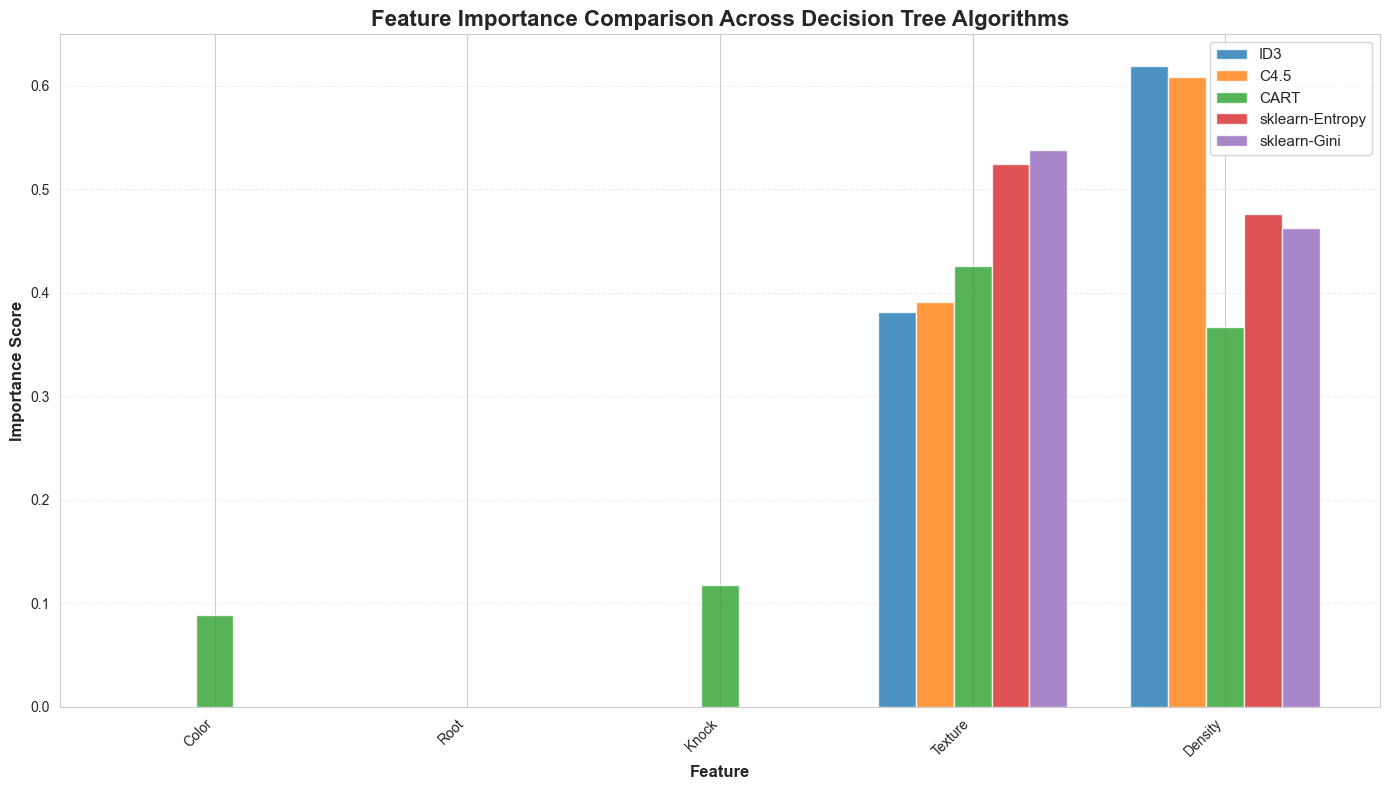

In [88]:
# 可视化1：特征重要性对比柱状图
# 中文到英文名称映射
feature_name_mapping = {
    '编号': 'No',
    '色泽': 'Color',
    '根蒂': 'Root',
    '敲声': 'Knock',
    '纹理': 'Texture',
    '密度': 'Density'
}

# 生成英文特征名列表（保持顺序）
all_features_en = [feature_name_mapping.get(f, f) for f in all_features]

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(all_features_en))
width = 0.15

bars1 = ax.bar(x - 2*width, importance_df['ID3'], width, label='ID3', alpha=0.8)
bars2 = ax.bar(x - width, importance_df['C4.5'], width, label='C4.5', alpha=0.8)
bars3 = ax.bar(x, importance_df['CART'], width, label='CART', alpha=0.8)
bars4 = ax.bar(x + width, importance_df['sklearn-Entropy'], width, label='sklearn-Entropy', alpha=0.8)
bars5 = ax.bar(x + 2*width, importance_df['sklearn-Gini'], width, label='sklearn-Gini', alpha=0.8)

ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Comparison Across Decision Tree Algorithms', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_features_en, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("pic/feature_importance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()



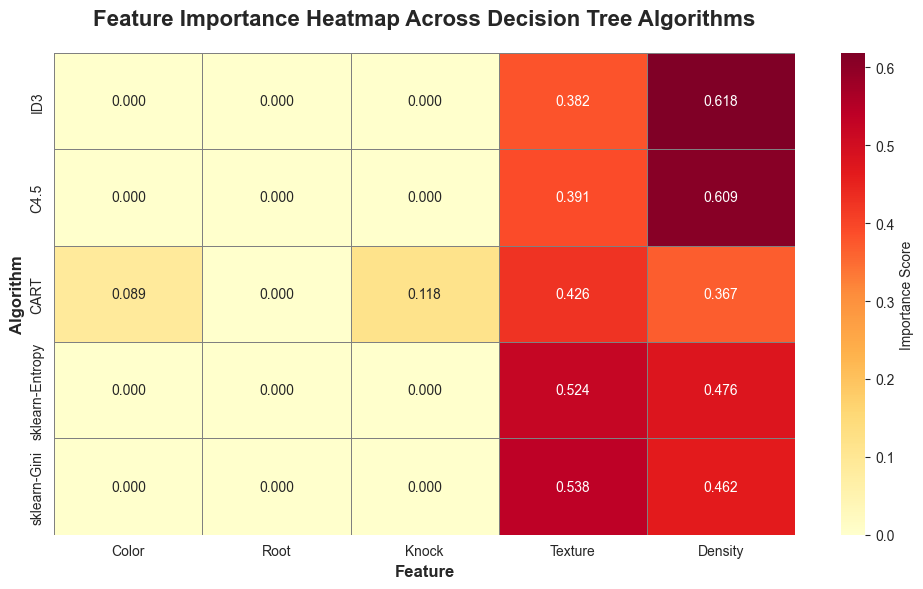

In [89]:
# 可视化2：特征重要性热力图
fig, ax = plt.subplots(figsize=(10, 6))

# 准备数据：将“特征”列映射为英文名
importance_df_en = importance_df.copy()
importance_df_en['特征'] = importance_df_en['特征'].map(feature_name_mapping)
heatmap_data = importance_df_en.set_index('特征').T

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Importance Score'}, ax=ax, 
            linewidths=0.5, linecolor='gray')

ax.set_title('Feature Importance Heatmap Across Decision Tree Algorithms', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("pic/feature_importance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


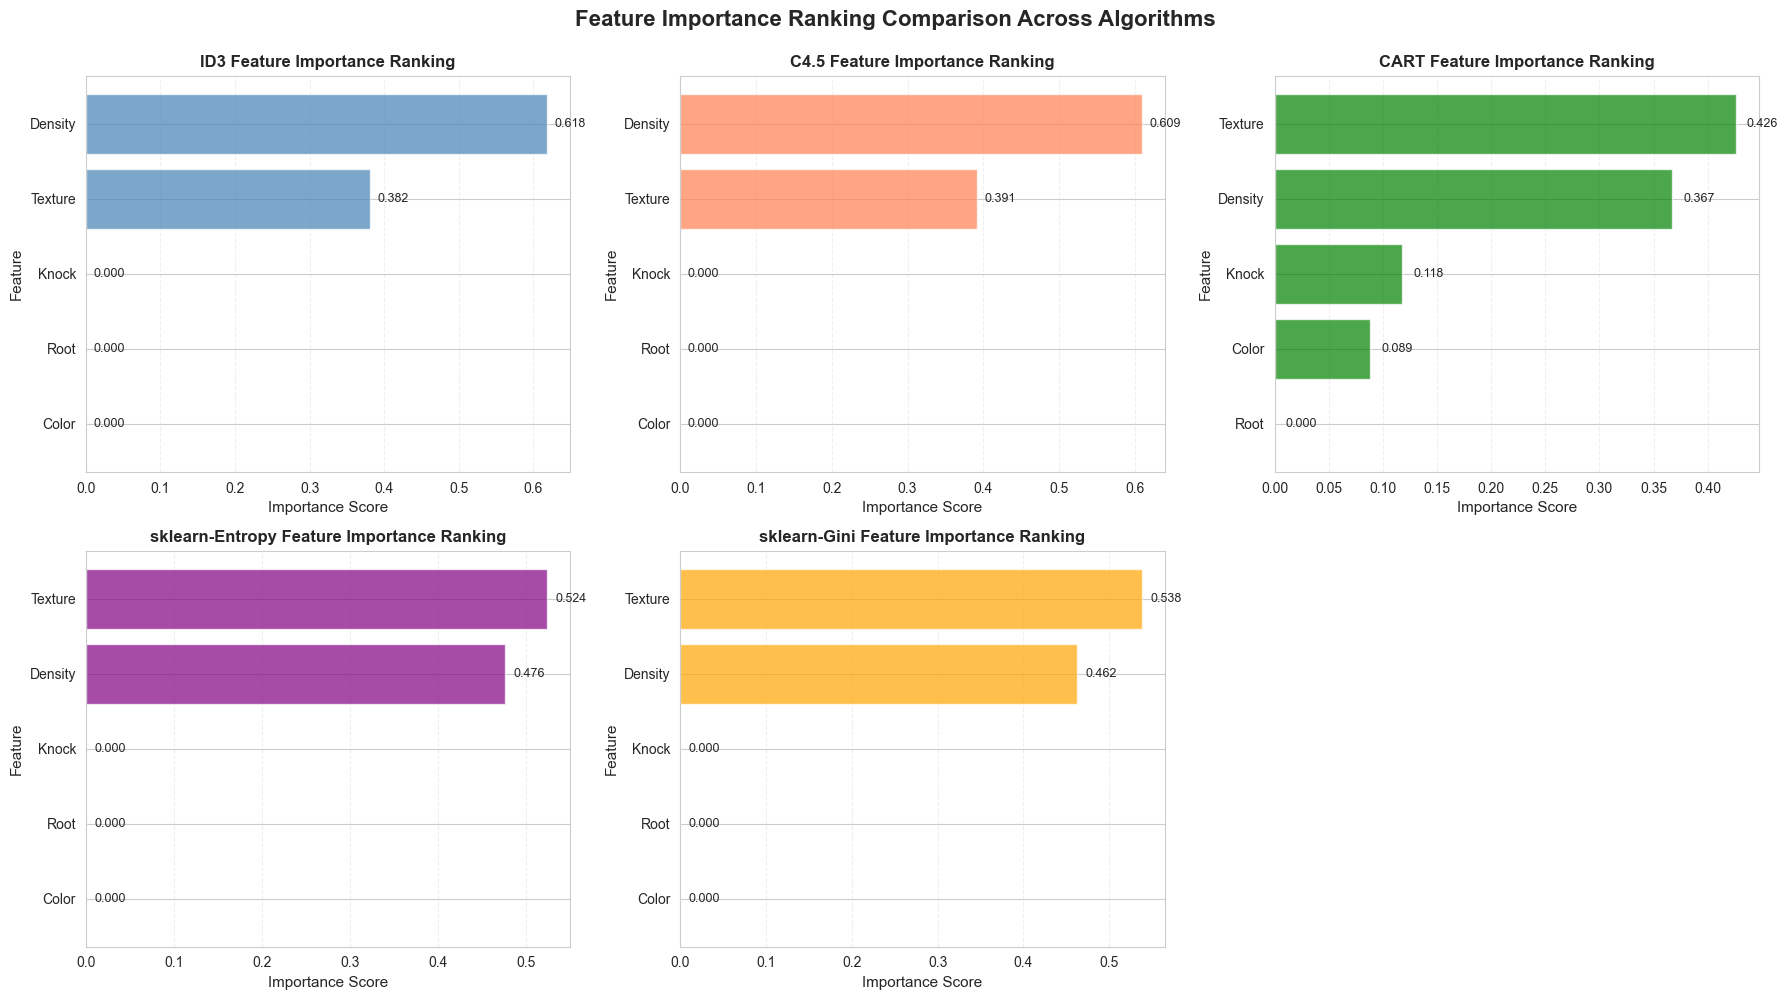

In [90]:
# 可视化3：各算法的特征重要性排序（横向条形图）
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

algorithms = ['ID3', 'C4.5', 'CART', 'sklearn-Entropy', 'sklearn-Gini']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for idx, algo in enumerate(algorithms):
    ax = axes[idx]
    
    # 获取该算法的特征重要性并排序，并将“特征”列映射为英文名
    algo_importance = importance_df[['特征', algo]].copy()
    algo_importance['特征'] = algo_importance['特征'].map(feature_name_mapping)
    algo_importance = algo_importance.sort_values(by=algo, ascending=True)
    
    # 绘制横向条形图
    bars = ax.barh(algo_importance['特征'], algo_importance[algo], color=colors[idx], alpha=0.7)
    
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_ylabel('Feature', fontsize=11)
    ax.set_title(f'{algo} Feature Importance Ranking', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # 添加数值标签
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)

# 隐藏第6个子图
axes[5].axis('off')

plt.suptitle('Feature Importance Ranking Comparison Across Algorithms', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("pic/feature_importance_barh.png", dpi=150, bbox_inches='tight')
plt.show()


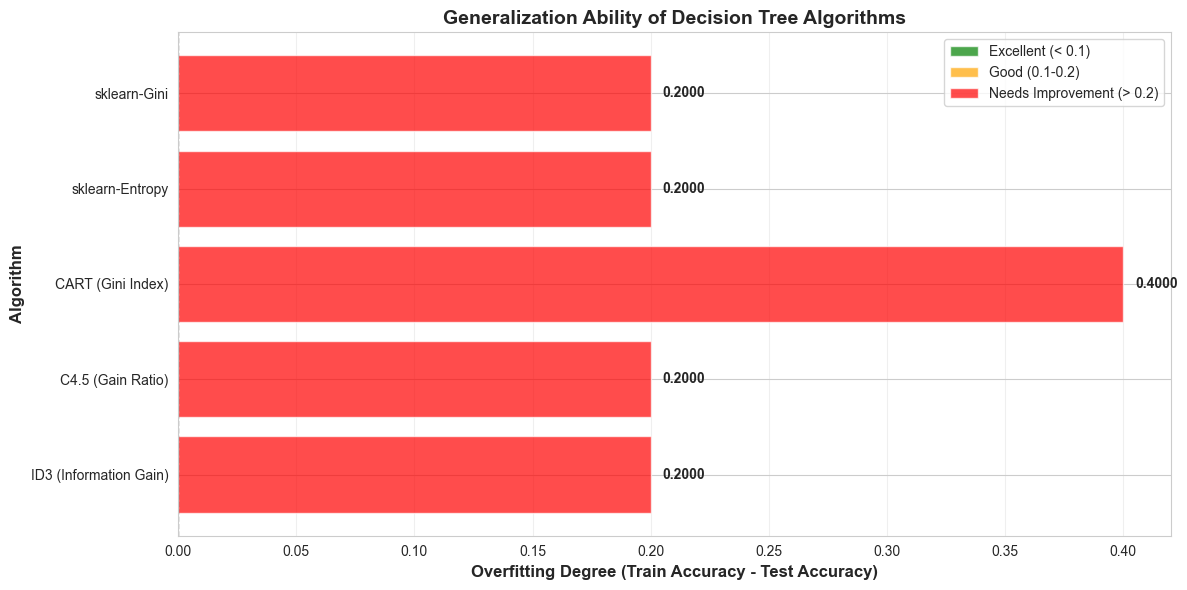

In [ ]:
# 先计算过拟合程度，加入results后再进行可视化
if '过拟合程度' not in results.columns:
    results['过拟合程度'] = (results['训练集准确率'] - results['测试集准确率']).round(4)

# Visualization 4: Generalization Comparison (Overfitting Degree)
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x < 0.1 else 'orange' if x < 0.2 else 'red' 
          for x in results['过拟合程度']]

bars = ax.barh(results['算法'], results['过拟合程度'], color=colors, alpha=0.7)
ax.set_xlabel('Overfitting Degree (Train Accuracy - Test Accuracy)', fontsize=12, fontweight='bold')
ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_title('Generalization Ability of Decision Tree Algorithms', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, results['过拟合程度'])):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}',
            va='center', fontsize=10, fontweight='bold')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Excellent (< 0.1)'),
    Patch(facecolor='orange', alpha=0.7, label='Good (0.1-0.2)'),
    Patch(facecolor='red', alpha=0.7, label='Needs Improvement (> 0.2)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("pic/overfitting_barh.png", dpi=150, bbox_inches='tight')
plt.show()

